#### PAT-1118 电话号码
1. 想办法分离数字和运算符
    - 可将输入分为两类：**有运算符的**，**无运算符的**。
        - 有运算符：**以运算符为分隔符**，```split()```返回**数字或者数字的拼音**组成的**列表**，转换后添加入```input_num```,同时将这个运算符添```input_op```
        - 无运算符：**纯数字或者纯数字拼音**，判断是数字就直接添加到数字列表，拼音就转换一下
2. 剩下的就是按照```input_op```的顺序来对```input_num```里的数字进行运算了.

In [2]:
input = make_input(
    """
er/2
3+2
sqrt9
sqrtjiu
6%2
san
5-2
9/3
1*3
er^san
8/2  
    """
)
# 1118-电话号码
# 二维列表，存储每一行的数字和运算符
input_str = list(input() for _ in range(11))

# 数字和拼音的映射
word_to_num = ["ling", "yi", "er", "san", "si", "wu", "liu", "qi", "ba", "jiu"]

# 支持的运算符
valid_op = ['sqrt', '+', '-', '*', '/', '%', '^']

# 存储分离后的数字
input_num = []

# 存储分离后的运算符
input_op = []

# 对每一行进行处理
for line in input_str:
    found_operator = False
    
    # 检查每个可能的运算符
    for op in valid_op:
        if op in line:
            input_op.append(op)
            parts = line.split(op)
            print(parts)
            # 转换数字部分
            temp = []
            for part in parts:
                if part.isdigit():
                    temp.append(int(part))
                elif part in word_to_num:
                    temp.append(word_to_num.index(part))

            
            input_num.append(temp)
            found_operator = True
            break
    
    # 如果没有找到运算符
    if not found_operator:
        input_op.append(' ')  # 空格表示没有运算符
        
        if line.isdigit():
            input_num.append([int(line)])
        else:
            input_num.append([word_to_num.index(line)])

# 计算每个表达式的结果
mobile_number = []
for i in range(11):
    if input_op[i] == ' ':
        mobile_number.append(input_num[i])
        continue
    
    num1, num2 = input_num[i][0], input_num[i][1] if len(input_num[i]) > 1 else 0
    
    if input_op[i] == 'sqrt':
        mobile_number.append([int(num1 ** 0.5)])
    elif input_op[i] == '+':
        mobile_number.append([num1 + num2])
    elif input_op[i] == '-':
        mobile_number.append([num1 - num2])
    elif input_op[i] == '*':
        mobile_number.append([num1 * num2])
    elif input_op[i] == '/':
        mobile_number.append([num1 // num2])
    elif input_op[i] == '%':
        mobile_number.append([num1 % num2])
    elif input_op[i] == '^':
        mobile_number.append([num1 ** num2])

# 输出结果
print(input_str)
print(input_num)
print(input_op)
print(''.join(''.join(str(num) for num in item) for item in mobile_number))

['er', '2']
['3', '2']
['', '9']
['', 'jiu']
['6', '2']
['5', '2']
['9', '3']
['1', '3']
['er', 'san']
['8', '2']
['er/2', '3+2', 'sqrt9', 'sqrtjiu', '6%2', 'san', '5-2', '9/3', '1*3', 'er^san', '8/2']
[[2, 2], [3, 2], [9], [9], [6, 2], [3], [5, 2], [9, 3], [1, 3], [2, 3], [8, 2]]
['/', '+', 'sqrt', 'sqrt', '%', ' ', '-', '/', '*', '^', '/']
15330333384


In [ ]:
#1118
import sys, math

def eval_one(expr: str) -> str:
    cn = {'ling':0,'yi':1,'er':2,'san':3,'si':4,'wu':5,'liu':6,'qi':7,'ba':8,'jiu':9}
    if expr in cn:
        return str(cn[expr])
    if expr.startswith('sqrt'):
        n = int(expr[4:])
        return str(int(math.isqrt(n)))  # 题目保证结果是一位整数
    # 手动找唯一二元运算符
    ops = set('+-*/%^')
    pos = -1
    op = ''
    for i, ch in enumerate(expr):
        if ch in ops:
            pos = i; op = ch; break
    a = int(expr[:pos]); b = int(expr[pos+1:])
    if op == '+': v = a + b
    elif op == '-': v = a - b
    elif op == '*': v = a * b
    elif op == '/': v = a // b
    elif op == '%': v = a % b
    else: v = a ** b
    return str(v)

if __name__ == '__main__':
    out = []
    for _ in range(11):
        line = sys.stdin.readline()
        if not line:
            line = ''  # 保底，避免异常
        expr = line.strip()
        # 保险：若表达式不含中文/sqrt/运算符，按数字直取
        try:
            out.append(eval_one(expr))
        except Exception:
            out.append(str(int(expr)))  # 题面保证结果为一位整数，这里兜底
    print(''.join(out))

#### PAT-1119 胖达与盆盆奶
1. 胖达类：
    - 胖达一次最少吃200毫升奶。
    - 感知左右同类的盆里的奶，但是只有相差100毫升以上才会感知到。
    - 当感知到相邻的同类盆里的奶比自己更多，并且自己更强（更胖）时，会去抢夺更多的奶。
2. 题目给出一排排好队的胖达的体重，要求不让胖达打乱队形的情况下，算出最少要多少奶。
3. 思路：
    - 双向遍历

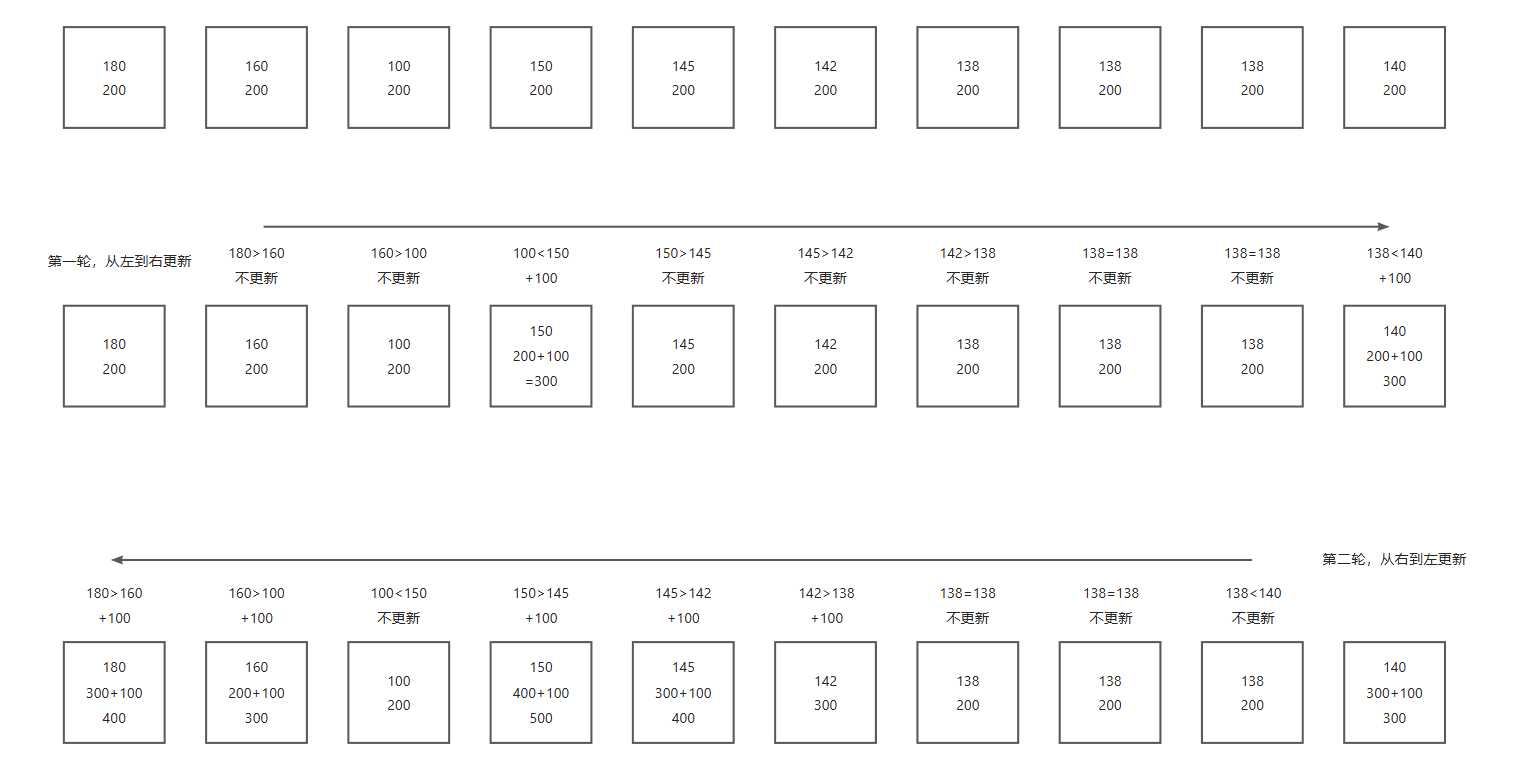

##### 何时使用双向遍历？
使用双向遍历的信号：

1. **约束来自两个方向**：问题的约束条件同时依赖于左边和右边的元素

2. **需要前后信息**：计算当前元素需要知道前面和后面的信息

3. **贪心性质**：问题具有局部最优可推导全局最优的性质

4. **O(n)复杂度要求**：需要线性时间复杂度的解决方案

关键特征：

1. 第一次遍历建立从左到右的依赖关系

2. 第二次遍历建立从右到左的依赖关系，**同时用max()或min()保护第一次遍历的结果**

3. 通常空间复杂度为O(n)，时间复杂度为O(n)

In [ ]:
input = make_input(
    """
10
180 160 100 150 145 142 138 138 138 140
    """
)

N = int(input())
weights = list(map(int, input().split()))
milk = [200] * N  # 所有奶牛初始至少200单位

# 从左到右遍历，确保右边体重大的获得更多
for i in range(1, N):
    if weights[i] > weights[i - 1]:
        milk[i] = milk[i - 1] + 100
    elif weights[i] == weights[i - 1]:
        milk[i] = milk[i - 1]

# 从右到左遍历，确保左边体重大的获得更多
for i in range(N - 2, -1, -1):
    if weights[i] > weights[i + 1]:
        # 确保不减少已经分配的奶量
        milk[i] = max(milk[i], milk[i + 1] + 100)
    elif weights[i] == weights[i + 1]:
        milk[i] = max(milk[i], milk[i + 1])

print(milk)
print(sum(milk))

[400, 300, 200, 500, 400, 300, 200, 200, 200, 300]
3000
